In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pyccl as ccl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline
from wale.CosmologyModel import *
from wale.CovarianceMatrix import *
from wale.InitializeVariables import *
from wale.VarianceCalculator import *
from wale.FilterFunctions import *
from wale.CommonUtils import *
from wale.CriticalPoints import *
from wale.ComputePDF import *
from wale.LoadSimulations import *

import cProfile, pstats


In [3]:
import numpy as np
import h5py
import healpy as hp
import multiprocessing as mp

class CosmoGridLoader:
    def __init__(self, data_path, nside_target=512):
        """
        data_path  : base directory containing CosmoGRID HDF5 files.
        nside_target: target Healpix resolution (CosmoGRID maps are at nside=512).
        """
        self.data_path = data_path
        self.nside_target = nside_target  # CosmoGRID maps are provided at nside=512

    def get_beam(self, theta, lmax):
        """
        Compute the beam transfer function for a top-hat filter.
        
        theta: smoothing scale in arcmin.
        lmax : maximum multipole.
        """
        def top_hat(b, radius):
            # Returns a top-hat filter; adjust normalization if needed.
            return np.where(np.abs(b) <= radius, 1/(np.cos(radius) - 1)/(-2*np.pi), 0)
        
        t = theta * np.pi / (60 * 180)  # convert arcmin to radians
        b = np.linspace(0.0, t * 1.2, 10000)
        bw = top_hat(b, t)
        beam = hp.sphtfunc.beam2bl(bw, b, lmax)
        return beam

    def smooth_map(self, args):
        """
        Smooth the input kappa map using the beam corresponding to the given theta.
        
        args: tuple (theta, lmax, kappa_map, nside)
        """
        theta, lmax, kappa_map, nside = args
        beam = self.get_beam(theta, lmax)
        almkappa = hp.sphtfunc.map2alm(kappa_map)
        kappa_smooth = hp.sphtfunc.alm2map(hp.sphtfunc.almxfl(almkappa, beam), nside)
        return kappa_smooth

    def load_cosmogrid_map(self, id_zbin, perm_index=0):
        """
        Load the base κ map from the CosmoGRID HDF5 file.
        
        id_zbin   : redshift bin index (e.g., 3 for the fourth bin)
        perm_index: simulation permutation index.
        """
        # For simplicity we use the "nobaryons" file; update if needed.
        file_path = f"{self.data_path}/projected_probes_maps_nobaryons512.h5"
        print(f"Loading CosmoGRID map from: {file_path}")
        with h5py.File(file_path, 'r') as f:
            # The dataset is assumed to be stored as 'kg/stage3_lensing{id_zbin+1}'
            dataset_name = f"kg/stage3_lensing{id_zbin+1}"
            print(f"Accessing dataset: {dataset_name}")
            kappa = np.array(f[dataset_name])
        # Ensure the map is at the target nside (though it should already be 512)
        kappa_target = hp.ud_grade(kappa, self.nside_target)
        return kappa_target

    def run_loader(self, theta, id_zbin=3, perm_index=0, nprocess=1):
        """
        Mimics TakahashiLoader.run_loader:
          - Loads the base CosmoGRID κ map.
          - Smooths it twice: once with θ and once with 2θ.
          - Computes the variance of the difference between the two smoothed maps.
          - For simplicity, assumes the source redshift is the mean n(z) (here set as a default).
        
        Parameters:
          theta     : primary smoothing scale in arcmin.
          id_zbin   : redshift bin index.
          perm_index: permutation index (to choose which simulation realization to load).
          nprocess  : number of processes to use for smoothing.
        
        Returns:
          variance  : variance of (kappa_smooth2 - kappa_smooth1).
          kappa_smooth1: map smoothed with θ.
          kappa_smooth2: map smoothed with 2θ.
        """
        # Load the base map (at nside=512)
        kappa = self.load_cosmogrid_map(id_zbin, perm_index)
        nside_target = self.nside_target
        lmax = nside_target * 3 - 1  # same as in Takahashi
        
        # Setup arguments for the two smoothing scales
        args1 = (theta, lmax, kappa, nside_target)
        args2 = (theta * 2, lmax, kappa, nside_target)
        
        # Use parallel processing if requested
        if nprocess > 1:
            with mp.Pool(processes=nprocess) as pool:
                kappa_smooth1, kappa_smooth2 = pool.map(self.smooth_map, [args1, args2])
        else:
            kappa_smooth1 = self.smooth_map(args1)
            kappa_smooth2 = self.smooth_map(args2)
            
        variance = np.var(kappa_smooth2 - kappa_smooth1)
        
        # For now, we take the mean of n(z) as our source redshift.
        # (Update this if you later have the actual n(z) distribution.)
        source_z = 0.9416
        print("Assumed source redshift (mean n(z)):", source_z)
        
        return variance, kappa_smooth1, kappa_smooth2

In [4]:
# param_file = "/Users/vilasini/Documents/WALE/data/selected_params_halofit_unique.npy"
# param_table = np.load(param_file)
# param_table


Now computing for the CosmoGRID simulation..
Loading CosmoGRID map from: /Users/vilasini/Documents/theory validation/cosmogrid/projected_probes_maps_nobaryons512.h5
Accessing dataset: kg/stage3_lensing4
Assumed source redshift (mean n(z)): 0.9416
Variance from CosmoGRID simulation: 4.6529087184844355e-06


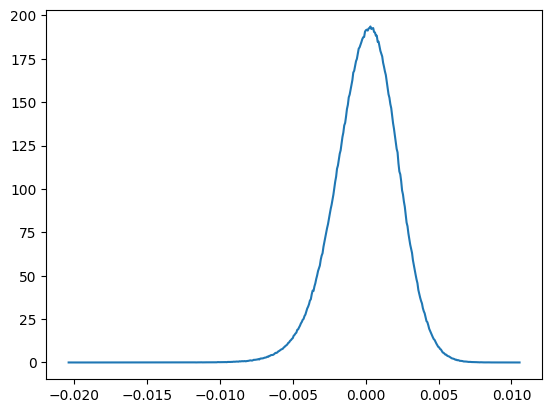

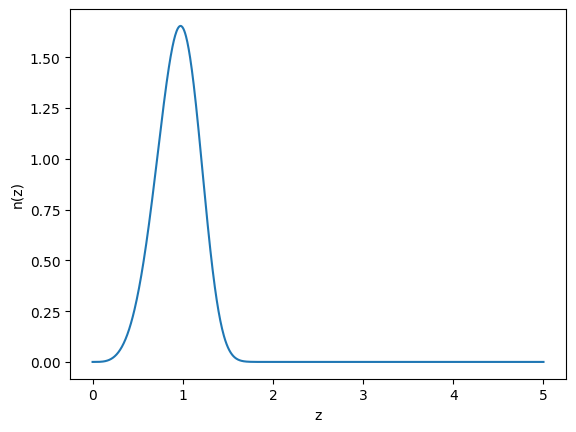

Using n(z) file: /Users/vilasini/Documents/WALE/data/nz/nz_stage3_4_GRID.txt
   Using scalar spectral index ns = 0.9649

Initialised Cosmology:
  h = 0.6736, Oc = 0.2107, Ob = 0.0493, w = -1.0, wa = 0.0, sigma8 = 0.84
  k-range: [0.001, 3.0] with step dk = 0.005

Initialising WALE with the following parameters:
   Initialised Variables:
      Source redshift: from nz file
      Number of planes: 20
      Angular scale theta1 (radians): 0.008726646259971648, arcmin: 30.0
      Variability: disabled
 
   Variance module initialized...
  Computing σ²_κ at θ=30.00 arcmin using ℓ in [2.0, 20000.0]
  The ldt variance is: 4.757305615524944e-06
  The perturbation theory variance is: 4.765211543168026e-06
   The CosmoGRID variance is: 4.6529087184844355e-06
   The recalibration factor is: 1.0224369106201836
   Finding critical points (optimized)...
       Setting ngrid = 20. Increase for accuracy; runtime ~ O(ngrid^2).
       Smallest positive / largest negative: 348.9122248665722 / -374.691004

(-0.1, 0.30528854658552296)

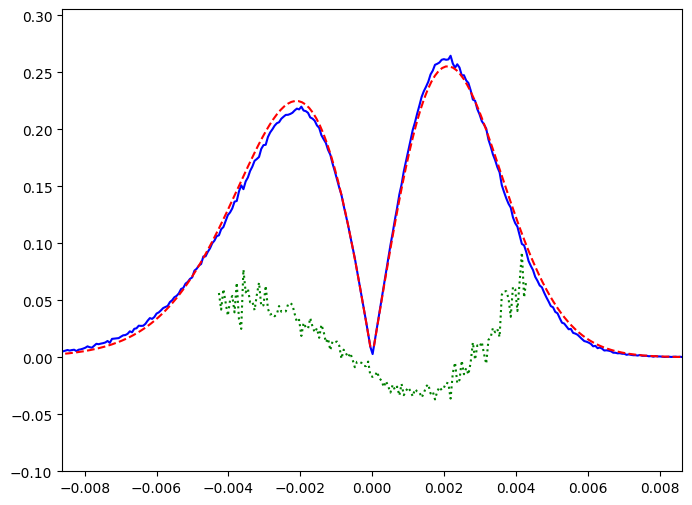

In [5]:
fid_map_path = "/Users/vilasini/Documents/theory validation/cosmogrid/projected_probes_maps_nobaryons512.h5"
id_zbin = 3  # Corresponds to the third redshift bin
nz_file = f"/Users/vilasini/Documents/WALE/data/nz/nz_stage3_{id_zbin+1}_GRID.txt"

# Flag to load CosmoGRID simulation data
load_cosmogrid = True
theta1_input = 30.0  # Smoothing scale in arcmin
if load_cosmogrid:
    print("\nNow computing for the CosmoGRID simulation..")
    
    # CosmoGRID maps are at nside=512, and we use the same smoothing logic.
    loader = CosmoGridLoader(data_path="/Users/vilasini/Documents/theory validation/cosmogrid", nside_target=512)
    
    # 'theta' is your smoothing scale in arcmin; id_zbin is the desired redshift bin.
    variance_cosmogrid, kmap1, kmap2 = loader.run_loader(theta=theta1_input, id_zbin=id_zbin, perm_index=0, nprocess=1)
    
    # Compute the mass map difference (smoothed with 2θ vs. θ)
    k_massmap_simulation = kmap2 - kmap1
    
    # Calculate the PDF of the simulation
    pdf_simulation, bin_edges = np.histogram(k_massmap_simulation, bins=500, density=True)
    kappa_sim = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    print("Variance from CosmoGRID simulation:", variance_cosmogrid)

    plt.plot(kappa_sim, pdf_simulation)

# --- Cosmology parameters ---
h = 0.6736
Ob = 0.0493
w = -1.0
wa = 0.0
sigma8 = 0.84
Om = 2.6e-01
Oc = Om - Ob
ns = 0.9649

plt.figure()
plt.plot(*np.loadtxt(nz_file).T)
plt.xlabel("z")
plt.ylabel("n(z)")
plt.show()
print(f"Using n(z) file: {nz_file}")
theta1 = theta1_input  # in arcmin
filter_type = 'tophat'
snr = np.linspace(-3, 3, 300)

variables = InitialiseVariables(
h=h, Oc=Oc, Ob=Ob, w=w, wa=wa, sigma8=sigma8,
dk=0.005, kmin=1e-3, kmax=3.,
nz_file=nz_file, variability=False,
theta1=theta1, nplanes=20, ns=ns )

# Compute sigma^2 maps
variance = Variance(variables.cosmo, filter_type=filter_type, pk=variables.cosmo.pnl)
variables.sigmasq_map = np.sum(
    variables.dchi * (variables.lensingweights ** 2) * np.array([
        variance.get_sig_slice(z, chi * variables.theta1_radian, chi * variables.theta2_radian)
        for z, chi in zip(variables.redshifts, variables.chis)
    ])
)

# Theory (perturbation) sigma^2
theory_sigmasq = compute_sigma_kappa_squared(
    theta1, variables.chis, variables.lensingweights,
    variables.redshifts, variables.cosmo.k, variables.cosmo.pnl,
    filter_type=filter_type, h=h
)

variables.recal_value = variables.sigmasq_map / (variance_cosmogrid)
    
print(f"  The ldt variance is: {variables.sigmasq_map}")
print(f"  The perturbation theory variance is: {theory_sigmasq}") 
print(f"   The CosmoGRID variance is: {variance_cosmogrid}")
print(f"   The recalibration factor is: {variables.recal_value}")
        
# Critical points and lambdas
smallest_positive, largest_negative = find_critical_points_for_cosmo(
    variables, variance, ngrid_critical=20, plot=False, min_z=0, max_z=5
)
if smallest_positive and largest_negative is not None:
    variables.lambdas = np.linspace(largest_negative, smallest_positive, 20)
    
# Compute PDF and L1
computed_PDF = computePDF(variables, variance, plot_scgf=False)
pdf_vals, kappa_vals = computed_PDF.pdf_values, computed_PDF.kappa_values
norm_kappa = kappa_vals / np.sqrt(theory_sigmasq)
prediction_pdf = CubicSpline(norm_kappa, pdf_vals)(snr)
prediction_l1 = CubicSpline(norm_kappa, np.abs(kappa_vals) * pdf_vals)(snr)

# Store results
pred_stats = get_moments(kappa_vals, pdf_vals)            
print(f"  predstats: mean: {pred_stats[0]}, variance: {pred_stats[1]}, s3: {pred_stats[2]:.3f}, kurtosis: {pred_stats[3]:.3f}, norm: {pred_stats[4]:.3f}")
sim_stats = get_moments(kappa_sim, pdf_simulation)
print(f"  simstats: mean: {sim_stats[0]}, variance: {sim_stats[1]}, s3: {sim_stats[2]:.3f}, kurtosis: {sim_stats[3]:.3f}, norm: {sim_stats[4]:.3f}")
    
# --- Plotting ---
plt.figure(figsize=(8,6))
plt.plot(kappa_sim, pdf_simulation*np.abs(kappa_sim), label='CosmoGRID Simulation', color='blue')
plt.plot(kappa_vals, pdf_vals*np.abs(kappa_vals), label='Perturbation Theory', color='red', linestyle='--')
residual = (CubicSpline(kappa_vals, pdf_vals)(kappa_sim) - pdf_simulation) / (pdf_simulation + 1e-12)
mask = np.where((kappa_sim >= -2*np.std(k_massmap_simulation)) & (kappa_sim <= 2*np.std(k_massmap_simulation)) )
plt.plot(kappa_sim[mask], residual[mask], label='Residual', color='green', linestyle=':')
plt.xlim(-4*np.std(k_massmap_simulation), 4*np.std(k_massmap_simulation))
plt.ylim(-0.1, np.max(prediction_l1)+0.05)